<a href="https://colab.research.google.com/github/nbosnjovic/NASP-Poredjenje-performansi-Dijkstra-algoritma/blob/main/Pore%C4%91enje_performansi_Dijkstra_algoritma_implementiranog_s_binarnom_i_Fibonaccijevom_gomilom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install networkx pandas matplotlib tqdm

In [ ]:
# @title Implementacija: Dijkstra (binarni heap i Fibonaccijeva gomila)
import math, heapq
from typing import Dict, List, Tuple, Any
import networkx as nx

# Dijkstra (binary heap preko heapq)
def dijkstra_binary_heap(G: nx.Graph, source: Any) -> Dict[Any, float]:
    dist = {v: math.inf for v in G.nodes}
    dist[source] = 0.0
    visited = set()
    pq = [(0.0, source)]
    while pq:
        d, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        for v, attrs in G[u].items():
            w = attrs.get("weight", 1.0)
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
    return dist

In [ ]:
# Fibonacci Heap minimalna implementacija
class FibNode:
    __slots__=("key","val","deg","mark","p","child","l","r")
    def __init__(self, key, val):
        self.key=key; self.val=val
        self.deg=0; self.mark=False
        self.p=None; self.child=None
        self.l=self; self.r=self

class FibonacciHeap:
    def __init__(self):
        self.min=None
        self.n=0
        self.loc={}

    def _add_root(self,x):
        if self.min is None:
            x.l=x.r=x
        else:
            x.l=self.min
            x.r=self.min.r
            self.min.r.l=x
            self.min.r=x

    def _remove_from_list(self,x):
        x.l.r=x.r
        x.r.l=x.l
        x.l=x.r=x

    def insert(self,key,val):
        x=FibNode(key,val)
        self.loc[val]=x
        self._add_root(x)
        if self.min is None or x.key<self.min.key:
            self.min=x
        self.n += 1
        return x

    def _remove_from_child(self,p,x):
        if x.r is x:
            p.child=None
        else:
            if p.child is x:
                p.child=x.r
            x.l.r=x.r
            x.r.l=x.l
        x.l=x.r=x
        p.deg -= 1

    def _link(self,y,x):
        self._remove_from_list(y)
        y.p=x
        if x.child is None:
            x.child=y
            y.l=y.r=y
        else:
            y.l=x.child
            y.r=x.child.r
            x.child.r.l=y
            x.child.r=y
        x.deg += 1
        y.mark=False

    def _consolidate(self):
        if self.n == 0 or self.min is None:
            return

        import math as _m
        phi = (1 + _m.sqrt(5)) / 2
        D = int(_m.log(self.n, phi)) + 10
        A = [None] * (D + 1)

        roots=[]
        w=self.min
        while True:
            roots.append(w)
            w=w.r
            if w is self.min:
                break

        for w in roots:
            x=w
            d=x.deg

            while d >= len(A):
                A.extend([None] * len(A))

            while A[d] is not None:
                y=A[d]
                if y.key < x.key:
                    x,y=y,x
                self._link(y,x)
                A[d]=None
                d += 1
                while d >= len(A):
                    A.extend([None] * len(A))

            A[d]=x

        self.min=None
        for a in A:
            if a is not None:
                a.l=a.r=a
                if self.min is None:
                    self.min=a
                else:
                    a.l=self.min
                    a.r=self.min.r
                    self.min.r.l=a
                    self.min.r=a
                    if a.key < self.min.key:
                        self.min=a

    def extract_min(self):
        z = self.min
        if z is not None:
            # prebaci djecu u root list
            if z.child is not None:
                ch=[]
                c=z.child
                while True:
                    ch.append(c)
                    c=c.r
                    if c is z.child:
                        break
                for x in ch:
                    self._remove_from_child(z,x)
                    self._add_root(x)
                    x.p=None

            # sačuvaj sljedeći root prije uklanjanja
            next_root = z.r

            # ukloni z iz root liste
            self._remove_from_list(z)

            # odluči da li je heap prazan
            if next_root is z:
                self.min=None
            else:
                self.min=next_root
                self._consolidate()

            self.n -= 1
            self.loc.pop(z.val, None)

        return z

    def decrease_key(self,val,new_key):
        x=self.loc.get(val,None)
        if x is None or new_key > x.key:
            return
        x.key=new_key
        y=x.p

        if y is not None and x.key < y.key:
            # cut x iz y
            if x.r is x:
                y.child=None
            else:
                if y.child is x:
                    y.child=x.r
                x.l.r=x.r
                x.r.l=x.l
            x.l=x.r=x
            y.deg -= 1

            x.p=None
            x.mark=False
            self._add_root(x)
            self._cascading_cut(y)

        if self.min is None or x.key < self.min.key:
            self.min=x

    def _cascading_cut(self,y):
        z=y.p
        if z is not None:
            if not y.mark:
                y.mark=True
            else:
                # cut y iz z
                if y.r is y:
                    z.child=None
                else:
                    if z.child is y:
                        z.child=y.r
                    y.l.r=y.r
                    y.r.l=y.l
                y.l=y.r=y
                y.p=None
                y.mark=False
                self._add_root(y)
                self._cascading_cut(z)

    def is_empty(self):
        return self.n == 0

In [ ]:
# Dijkstra (Fibonacci heap)
def dijkstra_fibonacci_heap(G: nx.Graph, source: Any) -> Dict[Any, float]:
    dist = {v: math.inf for v in G.nodes}
    dist[source] = 0.0
    H = FibonacciHeap()
    for v in G.nodes:
        H.insert(dist[v], v)
    visited = set()
    while not H.is_empty():
        node = H.extract_min()
        if node is None: break
        u = node.val
        du = node.key
        if du > dist[u]:  # stale entry
            continue
        visited.add(u)
        for v, attrs in G[u].items():
            if v in visited:
                continue
            w = attrs.get("weight", 1.0)
            nd = du + w
            if nd < dist[v]:
                dist[v] = nd
                H.decrease_key(v, nd)
    return dist

In [ ]:
def make_weighted_graph(n: int, m: int, w_low: int = 1, w_high: int = 10, seed: int = 42) -> nx.Graph:

#Kreira nasumičan (uglavnom) povezan graf sa n čvorova i m grana, sa nasumičnim težinama u [w_low, w_high].
#Ako graf nije povezan, ručno spajamo komponente dodatnim granama.

    random.seed(seed)
    G = nx.gnm_random_graph(n, m, seed=seed, directed=False)

    # Ako nije povezan, spojimo komponente nasumičnim granama
    if not nx.is_connected(G):
        comps = list(nx.connected_components(G))
        # Uzmemo prvu komponentu kao "baznu"
        base = set(comps[0])
        for comp in comps[1:]:
            comp = list(comp)
            u = random.choice(comp)
            v = random.choice(list(base))
            G.add_edge(u, v)
            base.update(comp)

    # Dodaj težine na sve grane
    for u, v in G.edges():
        G[u][v]["weight"] = random.randint(w_low, w_high)

    return G

In [ ]:
# @title Benchmark: izvođenje i provjera identičnosti rezultata
import time
import pandas as pd
from tqdm import tqdm
import random

def run_benchmarks(configs, repeats=2, seed0=100):
    rows = []
    for (n, m, label) in configs:
        t_bin, t_fib, ok_all = [], [], True
        for r in range(repeats):
            G = make_weighted_graph(n, m, seed=seed0 + r)
            src = 0
            t0 = time.time()
            d1 = dijkstra_binary_heap(G, src)
            tb = time.time() - t0

            t0 = time.time()
            d2 = dijkstra_fibonacci_heap(G, src)
            tf = time.time() - t0

            same = all(abs(d1[v] - d2[v]) < 1e-9 for v in G.nodes)
            ok_all = ok_all and same
            t_bin.append(tb); t_fib.append(tf)

        rows.append({
            "nodes": n,
            "edges": m,
            "density": label,
            "time_binary_heap_s": sum(t_bin)/len(t_bin),
            "time_fibonacci_heap_s": sum(t_fib)/len(t_fib),
            "distances_equal": ok_all
        })
    return pd.DataFrame(rows)

# Konfiguracije (slobodno povecati za jace testove)
sparse_cfg = [(300, 900, "sparse"), (600, 1800, "sparse"), (1200, 3600, "sparse")]
dense_cfg  = [(300, 6000, "dense"), (600, 12000, "dense"), (1200, 36000, "dense")]

df_sparse = run_benchmarks(sparse_cfg, repeats=2, seed0=11)
df_dense  = run_benchmarks(dense_cfg,  repeats=2, seed0=22)
df = pd.concat([df_sparse, df_dense], ignore_index=True)

df


,nodes,edges,density,time_binary_heap_s,time_fibonacci_heap_s,distances_equal
0,300,900,sparse,0.001325,0.003578,True
1,600,1800,sparse,0.002872,0.009608,True
2,1200,3600,sparse,0.005050,0.015060,True
3,300,6000,dense,0.004373,0.005708,True
4,600,12000,dense,0.010792,0.013909,True
5,1200,36000,dense,0.036877,0.039500,True


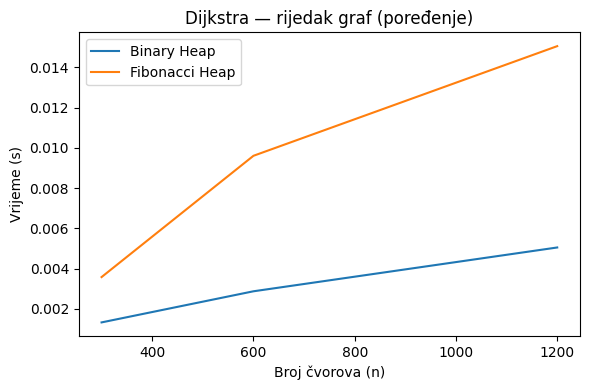

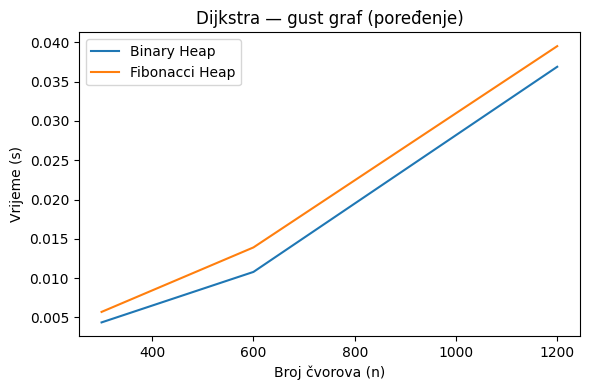

In [ ]:
# @title Grafovi i CSV
import matplotlib.pyplot as plt

df.to_csv("dijkstra_compare_results.csv", index=False)

def plot_group(df_group, title, out_path):
    g = df_group.sort_values("nodes")
    plt.figure(figsize=(6,4))
    plt.plot(g["nodes"], g["time_binary_heap_s"], label="Binary Heap")
    plt.plot(g["nodes"], g["time_fibonacci_heap_s"], label="Fibonacci Heap")
    plt.title(title)
    plt.xlabel("Broj čvorova (n)")
    plt.ylabel("Vrijeme (s)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=140)
    plt.show()

plot_group(df[df["density"]=="sparse"], "Dijkstra — rijedak graf (poređenje)", "plot_sparse.png")
plot_group(df[df["density"]=="dense"],  "Dijkstra — gust graf (poređenje)",   "plot_dense.png")
